## Practical session 5: Logistic regression with the stochastic proximal gradient algorithm

The goal of today's session is to implement the proximal gradient algorithm, which allows to minimize objective functions written as the sum of a smooth and a non-smooth term. 
This algorithm will be investiagated over a logistic regression problem with a $\ell-1$ norm regularizer.

### Logistic regression with elastic net regularization

Recall the logistic regression setting from Sessions 3 and 5, where we are given some *data*  $\mathcal{D}$ consisting of $m$ *examples* $\{d_i\}$; each example consisting of a *feature* vector $a_i\in\mathbb{R}^d$ and a binary *observation* $b_i\in \mathcal{O} = \{-1,+1\}$: $\mathcal{D} = \{[a_i,b_i]\}_{i=1..m}$. In this practical session, we will consider the following optimization problem
\begin{align*}
\min_{x\in\mathbb{R}^d } F(x) := \frac{1}{m}  \sum_{i=1}^m  \log( 1+\exp(-b_i \langle a_i,x \rangle) ) + \frac{\lambda_2}{2} \|x\|_2^2 + \lambda_1 \| x \|_1.
\end{align*}
Compared to Sessions 3 and 5, we use a regularization term of the form $\frac{\lambda_2}{2} \| x \|^2 + \lambda_1 \| x \|_1$ combining the $\ell_2$ and $\ell_1$ norm. This type of regularization is often called the *elastic net* regularization, and generalizes the LASSO ($\lambda_2 = 0$) and ridge ($\lambda_1 = 0$) regressions.

Remark that the objective function $F$ is the sum of two functions:
- a smooth and strongly convex function $f$ defined for any $x \in \mathbb{R}^d$ by
$$
f(x) = \frac{1}{m}  \sum_{i=1}^m  \log( 1+\exp(-b_i \langle a_i,x \rangle) ) + \frac{\lambda_2}{2} \|x\|_2^2,
$$
- a non-smooth convex function $g$ defined for any $x \in \mathbb{R}^d$ by
$$
g(x) = \lambda_1 \| x \|_1.
$$
The file `problem1.py` contains oracles for $F, f, g$ and $\nabla f$, as well as useful constants.

### The proximal gradient algorithm

When facing the minimization of $F = f + g$, with $f$ smooth and $g$ non-smooth, the minimization of $f$ can be adressed with (possibly stochastic) gradient descent. Concerning the function $g$, we can compute the proximal operator of $g$ as
$$
\textrm{prox}_g(x) = \textrm{arg min}_{y \in \mathbb{R}^d} \left( g(y) + \frac{1}{2}\| y - x \|^2 \right),
$$
leading to the proximal-gradient algorithm, which can be thought as a generalization of the projected gradient descent algorithm. At iteration $k \in \mathbb{N}$, the proximal gradient algorithm with step size $\tau > 0$ updates the current iterate $x_k$ to $x_{k+1}$ following
$$
x_{k+1} = \textrm{prox}_{\tau g} ( x - \tau \nabla f(x)).
$$
Similarly to projected gradient descent, we need to be able to compute the proximal operator of $g$ efficiently in order to run the proximal gradient algorithm.
The proximal operator of the $\ell_1$ norm can be computed efficiently through the following component-wise formula. For any $x \in \mathbb{R}^d$ and any $i \in \{1,\dots,d\}$,
$$
(\textrm{prox}_{\tau \lambda_1 \| \cdot \|_1}(x))_i =
\begin{cases}
    x_i - \tau \lambda_1 &\textrm{ if } \tau \lambda_1 \geq x,\\
    0 &\textrm{ if } -\tau \lambda_1 \leq x \leq \tau \lambda_1,\\
    x_i + \tau \lambda_1 &\textrm{ otherwise}.
\end{cases}
$$

> Implement the above proximal operator in the file `problem1.py` (use $\tau$ and $\lambda_1$ as parameters of the operator).

> Complete the implementation of the proximal gradient algorithm in the file `algorithms.py` (treat $\lambda_1$ as a parameter of the algorithm), with stopping rule of the form $\| x_k - x_{k+1} \| \leq \epsilon$.

### Applying the proximal gradient algorithm

> Run you algorithm with $\tau = 1/L$, $\lambda_1 = 0.01$, starting from $x_0 = 0$. Observe the values of the objective function and the size of the support (the size of the support of $x \in \mathbb{R}^d$ is the number of non-zero components, also called the $\ell_0$ norm) of the iterates using the function `plot_obj_supportSize` from `utils.py`. What do you observe?

------------------------------------
 prox gradient with constant step size
------------------------------------
START
FINISHED -- 999 iterations -- 0.550349s -- final value: 0.539325 




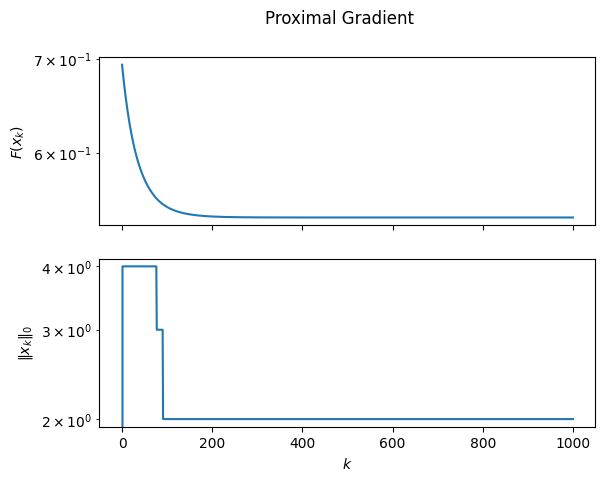

In [3]:
import problem1 as pb1
from utils import *
from algorithms import *
tau = 1/pb1.L
lambda1 = 0.1
x_init = np.zeros(pb1.n)
x, x_tab = prox_grad(pb1.F, pb1.grad_f, pb1.prox_g, x_init, tau, lambda1, iterMax=1000, prec=1e-6)
plot_obj_supportSize(x_tab, pb1.F, lambda1, title="Proximal Gradient")

> Compare the prediction performance on the test data set when $\lambda_1 = 0.01$ and when $\lambda_1 = 0$. 

In [12]:
#compare prediciton performance for different lambda
from problem1 import prediction_test


lambda1 = 0.1
x_init = np.zeros(pb1.n)
x, x_tab = prox_grad(pb1.F, pb1.grad_f, pb1.prox_g, x_init, tau, lambda1, iterMax=1000, prec=1e-6)
pred1, perf1 = prediction_test(x, PRINT=False)
print("lambda1 = ", lambda1, "prediction performance = ", perf1)

lambda2 = 0.0
x_init = np.zeros(pb1.n)
x, x_tab = prox_grad(pb1.F, pb1.grad_f, pb1.prox_g, x_init, tau, lambda2, iterMax=1000, prec=1e-6)
pred2, perf2 = prediction_test(x, PRINT=False)
print("lambda2 = ", lambda2, "prediction performance = ", perf2)

------------------------------------
 prox gradient with constant step size
------------------------------------
START
FINISHED -- 999 iterations -- 1.954616s -- final value: 0.539325 


lambda1 =  0.1 prediction performance =  0.8210526315789474
------------------------------------
 prox gradient with constant step size
------------------------------------
START
FINISHED -- 999 iterations -- 1.945618s -- final value: 0.362487 


lambda2 =  0.0 prediction performance =  0.8736842105263158


### Regularization path and feature signification

The proximal gradient algorithm puts some coordinates of the iterates to zero, which can be thought as selecting a subset of the features to be used for prediction. As $\lambda_1$ grows, less features will be selected. This influence can be understood by running the algorithm for many values of $\lambda_1$, and for each run, recording which features have been selected and the associated prediction error on the test data set. This amounts to drawing the so-called regularization path.


> For a given $\lambda_1$, denote by $x_{\lambda_1}$ the solution obtained by running the proximal gradient algorithm. Consider $\lambda_1 \in \{10^{-8}, 10^{-7}, \dots, 10^{-1}, 10^0, 10^1\}$. Plot as functions of $\lambda_1$ the following quantities:
> - the component of $x_{\lambda_1}$ (in one plot, one curve per dimension), 
> - the $\ell_0$ norm of $x_{\lambda_1}$, 
> - the prediction error on the test data set for each $x_{\lambda_1}$.
>
> What can you notice?

<>:39: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:39: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_6283/3063619341.py:39: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.ylabel('$x_\lambda$ component value')


------------------------------------
 prox gradient with constant step size
------------------------------------
START
FINISHED -- 999 iterations -- 1.216183s -- final value: 0.362487 


lambda =  1e-08 prediction performance =  0.8736842105263158
------------------------------------
 prox gradient with constant step size
------------------------------------
START
FINISHED -- 999 iterations -- 0.697358s -- final value: 0.362488 


lambda =  1e-07 prediction performance =  0.8736842105263158
------------------------------------
 prox gradient with constant step size
------------------------------------
START
FINISHED -- 999 iterations -- 0.544117s -- final value: 0.362491 


lambda =  1e-06 prediction performance =  0.8736842105263158
------------------------------------
 prox gradient with constant step size
------------------------------------
START
FINISHED -- 999 iterations -- 0.558571s -- final value: 0.362525 


lambda =  1e-05 prediction performance =  0.8736842105263158
--------

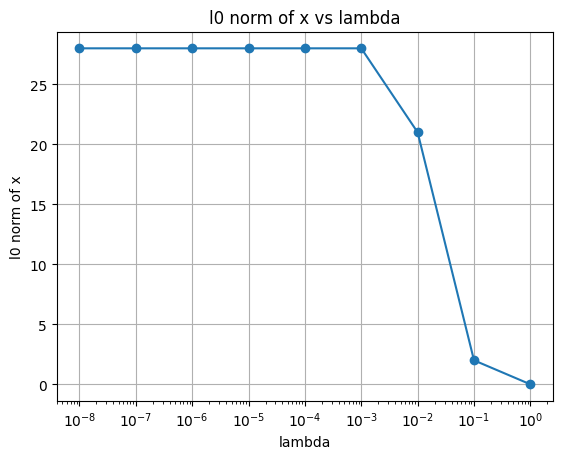

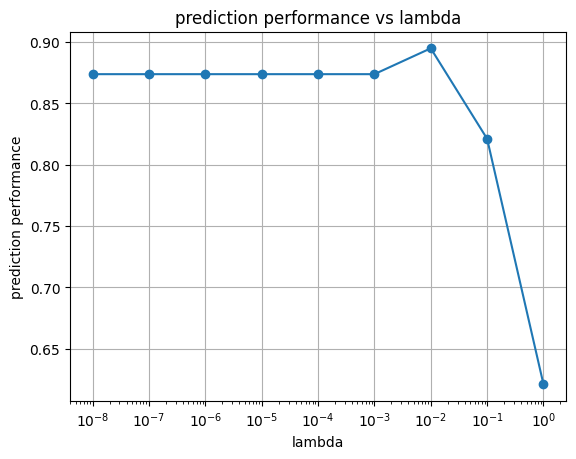

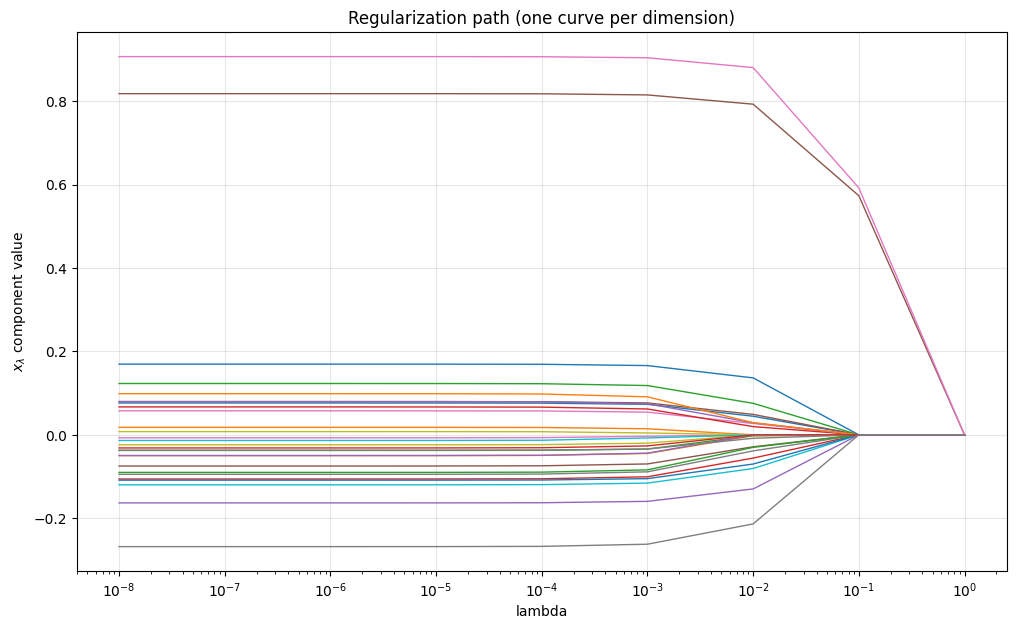

In [21]:
components = []
l0_norm = []
perf_tab = []
lambdas = [10**pow for pow in range(-8, 1)]

for lambda1 in lambdas:
    x_init = np.zeros(pb1.n)
    x, x_tab = prox_grad(pb1.F, pb1.grad_f, pb1.prox_g, x_init, tau, lambda1, iterMax=1000, prec=1e-6)
    pred, perf = prediction_test(x, PRINT=False)
    print("lambda = ", lambda1, "prediction performance = ", perf)
    perf_tab.append(perf)
    components.append(x.copy())
    l0_norm.append(np.sum(x != 0))

plt.figure()
plt.plot(lambdas, l0_norm, marker='o')
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('l0 norm of x')
plt.title('l0 norm of x vs lambda')
plt.grid()

plt.figure()
plt.plot(lambdas, perf_tab, marker='o')
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('prediction performance')
plt.title('prediction performance vs lambda')
plt.grid()
plt.show()

# Plot regularization path: one curve per feature dimension
components_arr = np.array(components)  # shape: (n_lambdas, n_features)
plt.figure(figsize=(12, 7))
for j in range(components_arr.shape[1]):
    plt.plot(lambdas, components_arr[:, j], linewidth=1)
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('$x_\lambda$ component value')
plt.title('Regularization path (one curve per dimension)')
plt.grid(alpha=0.3)
plt.show()